# Neural Network creation for Pump-valves block data

***

**Author:** Juan M. Montes-Sánchez

**GitHub:** https://github.com/juamonsan

***

In this notebook you will find a step by step guide where you will:
- Load data taken with FP-SNS-DATALOG1 on a STEVAL-MKSBOX1V1FP-SNS-DATALOG and pre-processed as .csv files with "Dataset preparation" notebook from this same project
- Split the data into train, evaluation and test
- Generate and train a Neural Network capable of classifing lectures from the sensors
- Evaluate the Neural Network with test data
- Generating plots and metrics related to the data or the Neural Network

## Requirements

You **MUST** have:
- Data in .csv and with a proper folder structure created with "Dataset preparation" notebook from this same project

Optional requirements include:
- CUDA compatible Nvidia GPU

## Previous steps

### Neural Network environment: Importing Keras/Tensorflow

Import tensorflow and check if we have GPUs availables. If so, it means a GPU is ready to be used for tensorflow training.

In [1]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam, SGD

from tensorflow.keras.utils import to_categorical

import sys

print("Python version {}.{}".format(sys.version_info.major, sys.version_info.minor))

print("Tensorflow version " + tf.__version__)

Python version 3.7
Tensorflow version 2.1.0


In [2]:
from tensorflow.python.client import device_lib

num_GPUs=len(tf.config.experimental.list_physical_devices('GPU'))

tf.config.list_physical_devices('GPU')

device_lib.list_local_devices()

tf.test.is_built_with_cuda()

tf.debugging.set_log_device_placement(True)


if(num_GPUs>0):
    print("Your system has {} GPUs availables".format(num_GPUs))
else:
    print("No GPUs available")    


Your system has 1 GPUs availables


---
If we have a Nvidia GPU with drivers and CUDA properly installed we can also get some extra information: GPU model, driver and CUDA versions, activity...

In [3]:
# GPU count and name
!nvidia-smi -L
# GPU activity
!nvidia-smi

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-235cadad-b6ee-9e16-4bcd-63bcc7b79e19)
Thu Jul  6 10:53:17 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 536.40                 Driver Version: 536.40       CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8               3W /  30W |    158MiB /  4096MiB |      5%      Default |
|                                         |                      |            

---
### Other imports

In [4]:
# More imports
import matplotlib.pyplot as plt #for plotting raw data
import os #for system folders and files management
import pathlib #for system folders and files management
import pandas as pd #for Dataframe handling

from IPython.display import display # for folder selection dialog
from ipyfilechooser import FileChooser # for folder selection dialog

import numpy as np
import math
import csv

import re #for character extraction

#for metrics and plots
import sklearn.model_selection
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import seaborn as sns #for plotting confusion matrix

# End

In [5]:
# Make numpy values easier to read (optional).
np.set_printoptions(precision=3, suppress=True)

### Definitions

In [6]:
# Plots a 3 axis data sample if given a .csv file
def plot_record(file_path, xName, yName):
    data = pd.read_csv(file_path, sep=',')
    data = data.to_numpy()
    print("Shape of the data is: {}".format(np.shape(data)))
    #plt.plot(data[:,0], data[:,1], #if we have a timestamp at column 0
    #         data[:,0], data[:,2],
    #         data[:,0], data[:,3])
    plt.plot(range(np.shape(data)[0]), data[:,0],
             range(np.shape(data)[0]), data[:,1],
             range(np.shape(data)[0]), data[:,2])
    plt.xlabel(xName)
    plt.ylabel(yName)
    #plt.xlim((0, 200))
    #plt.ylim((-1500, 1500))

## Loading data

### Loading from CSV



Select data folder and extract data size from the content of the files. We are going to consider the data is already in the desired format.

In [7]:
#Select sensor csv folder:

# Create and display a FileChooser widget
fc = FileChooser('./')
fc.show_only_dirs=True
print("--------------------------------\nSELECT TRAIN DATA SENSOR FOLDER\n--------------------------------")
display(fc)
print("--------------------------------\n")

--------------------------------
SELECT TRAIN DATA SENSOR FOLDER
--------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

--------------------------------



Number of samples: 1036
Sample size: 50
Number of features: 3
Frequency (from file folder name): 100
-----------------------
Plot example for first file:
-----------------------
The class for this file is 2
Shape of the data is: (49, 3)


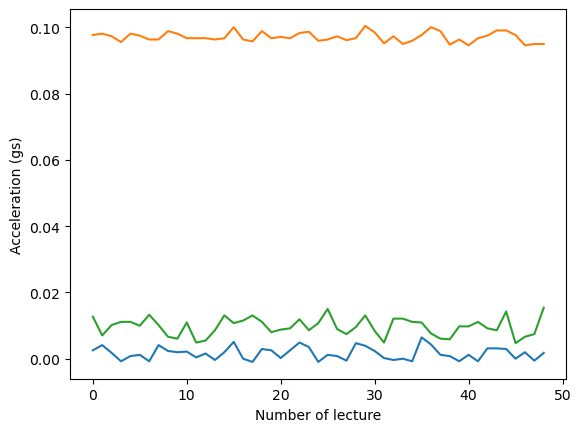

In [8]:
if fc.selected_path==None:
    print("--------------------------------------\n|  No data selected above!!          |\n|  Sample data will be used instead  |\n--------------------------------------")
    csv_folder_path="TEST_DATA\\expData\\STBOX_00001_Windows" #Select desired path
    sensor_folder="ACC_LIS3DHH_1100Hz" #Select desired sensor folder
    full_path=os.path.join(csv_folder_path,sensor_folder)
else:
    full_path = fc.selected_path
    sensor_folder=os.path.basename(os.path.normpath(full_path))

Current_file_path = os.path.join(full_path,os.listdir(full_path)[0])

Current_file = open(Current_file_path) # Open first file for counting rows

freq_samples=int(re.sub('[^0-9]','', sensor_folder[-7:-2])) #extracts the frequency from the directory name

num_samples= len(os.listdir(full_path)) #number of .csv files in total
tam_samples= len(Current_file.readlines())#number of lectures in a window sample (rows in each .csv)
num_features = 3 #axis number (3 for accel) TODO: read column number from the file

print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples,tam_samples,num_features))
print("Frequency (from file folder name): {}".format(freq_samples))
print("-----------------------\nPlot example for first file:\n-----------------------")

file_class=int(Current_file_path[-6:-4])-1 # Class is in the filename, at the end, just before file extension
print("The class for this file is {}".format(file_class))

plot_record(Current_file_path, 'Number of lecture', 'Acceleration (gs)')

Current_file.close() # Close file

Using the variables from above cell, we create two training numpy arrays for feeding the NN: one contains the data (trainX) and the other the desired outputs in one hot format (trainY)

In [9]:
DataX=np.empty([num_samples, tam_samples, num_features]) # Empty numpy array we will fill with data from .csv files
DataY=np.empty([num_samples])

for i in range (num_samples):
    Current_file_path = os.path.join(full_path,os.listdir(full_path)[i])
    Current_CSV=np.genfromtxt (Current_file_path, delimiter=",")
    DataX[i]=Current_CSV
    if np.any(np.isnan(DataX[i])):
        print(i)
        for k in range(0,len(DataX[i])):
            if np.any(np.isnan(DataX[i][k])):
                print("File {} in line {} is NaN".format(i,k))
    file_class=int(Current_file_path[-6:-4])
    DataY[i]=file_class-1 #first class is class 1, but now we start from 0
    #print("{} (Class {})".format(Current_file_path,file_class))
#    if file_class == 1:
#        DataY[i]='001'
#    elif file_class == 2:
#        DataY[i]='010'
#    elif file_class == 3:
#        DataY[i]='100'
#    else:
#        print("ERROR")
#        DataY[i]='000'

DataY = to_categorical(DataY)        
print("The shape of DataX array is: {}".format(np.shape(DataX))) # We check if the shape is correct
if np.any(np.isnan(DataX)):
    print("DANGER!! NaN values found in DataX!! Check exactly where above")
    
print("The shape of DataY array is: {}".format(np.shape(DataY))) 
if np.any(np.isnan(DataY)):
    print("DANGER!! NaN values found in DataY!!")
    

The shape of DataX array is: (1036, 50, 3)
The shape of DataY array is: (1036, 3)


#### Split the data

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(DataX, DataY, test_size=0.15, random_state=100, stratify=DataY)
print("X_train shape: {} || X_test shape: {}".format(np.shape(X_train), np.shape(X_test))) # We check if the shape is correct
print("y_train shape: {} || y_test shape: {}".format(np.shape(y_train), np.shape(y_test)))

X_train shape: (880, 50, 3) || X_test shape: (156, 50, 3)
y_train shape: (880, 3) || y_test shape: (156, 3)


### Network definition

In [11]:
#Copiado de notebook de Curro (definiciones de distintas RNN):

def create_1layer_lstm_model(nodes,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_1layer_gru_model(nodes,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_lstm_model(nodes_1stl,nodes_2ndl,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(LSTM((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_gru_model(nodes_1stl,nodes_2ndl,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(GRU((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model

#### NN training


In [33]:
#Model Creation

#Parameters
RNN_type = 'GRU' #specify GRU or LSTM
layers = 1 #specify 1 or 2 layers
nodes_1 = 8 # Specify nodes for first layer 32
nodes_2 = 4 # Specify nodes for second layer 16
drp = 0.3 # Specify droput rate

input_shape=(None,tam_samples, num_features) #this should not be changed since it depends on the loaded file

if RNN_type == 'GRU':
    if layers == 1:
        model_RNN = create_1layer_gru_model(nodes_1,drp,input_shape)
        model_RNN_name = 'GRU_1l_{}_{}Hz'.format(nodes_1,freq_samples)
    elif layer == 2:
        model_RNN = create_2layer_gru_model(nodes_1,nodes_2,drp,input_shape)
        model_RNN_name = 'GRU_2l_{}_{}_{}Hz'.format(nodes_1,nodes_2,freq_samples)
    else:
        print("ERROR, incorrect parameters")
elif RNN_type == 'LSTM':
    if layers == 1:
        model_RNN = create_1layer_lstm_model(nodes_1,drp,input_shape)
        model_RNN_name = 'LSTM_1l_{}_{}Hz'.format(nodes_1,freq_samples)
    elif layer == 2:
        model_RNN = create_2layer_lstm_model(nodes_1,nodes_2,drp,input_shape)
        model_RNN_name = 'LSTM_2l_{}_{}_{}Hz'.format(nodes_1,nodes_2,freq_samples)
    else:
        print("ERROR, incorrect parameters")
else:
    print("ERROR, incorrect parameters")

      
model_RNN.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_1 (Batch (None, 50, 3)             12        
_________________________________________________________________
gru_1 (GRU)                  (None, 8)                 312       
_________________________________________________________________
dropout_1 (Dropout)          (None, 8)                 0         
_________________________________________________________________
dense_1 (Dense)              (None, 3)                 27        
Total params: 351
Trainable params: 345
Non-trainable params: 6
_________________________________________________________________


In [36]:
#Model save

# Create model folder
models_folder = "DATA\\models"
#sensor_folder = sensor_folder # This was read some boxes before, when dataset was loaded
sensor_model_folder=os.path.join(models_folder,sensor_folder)
if not os.path.exists(sensor_model_folder): 
                os.makedirs(sensor_model_folder)
        
#set filename    
filename_txt="Summary_{}.txt".format(model_RNN_name)

#save summary report in a txt
with open(os.path.join(sensor_model_folder,filename_txt), 'w') as f:
    model_RNN.summary(print_fn=lambda x: f.write(x + '\n'))
f.close()

#plot model
tf.keras.utils.plot_model(
    model_RNN,
    #to_file="Model_{}.png".format(model_RNN_name),
    show_shapes=False,
    #show_dtype=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=96,
    #layer_range=None,
    #show_layer_activations=False,
    #show_trainable=False,
)


Failed to import pydot. You must install pydot and graphviz for `pydotprint` to work.


In [13]:
#Compile

opt = tf.keras.optimizers.Adam(learning_rate=0.002)

model_RNN.compile(loss='categorical_crossentropy',
        optimizer=opt,
        metrics=["accuracy"])

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0


In [14]:
#Train

epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=70, verbose=1),
]


#model_lstm_2l.fit(X_train, y_train, batch_size = batch_size,epochs = epochs, validation_data = (X_test, y_test))
with tf.device('/gpu:0'):
    history = model_RNN.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        validation_data = (X_test, y_test),
        verbose=1,
    )

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op Prefet

Epoch 14/500
880/880 [==============================] - 1s 684us/sample - loss: 1.0454 - accuracy: 0.4716 - val_loss: 1.0490 - val_accuracy: 0.4744
Epoch 15/500
880/880 [==============================] - 1s 1ms/sample - loss: 1.0444 - accuracy: 0.4716 - val_loss: 1.0477 - val_accuracy: 0.4744
Epoch 16/500
880/880 [==============================] - 1s 869us/sample - loss: 1.0414 - accuracy: 0.4716 - val_loss: 1.0492 - val_accuracy: 0.4744
Epoch 17/500
880/880 [==============================] - 1s 894us/sample - loss: 1.0439 - accuracy: 0.4716 - val_loss: 1.0479 - val_accuracy: 0.4744
Epoch 18/500
880/880 [==============================] - 1s 894us/sample - loss: 1.0385 - accuracy: 0.4693 - val_loss: 1.0512 - val_accuracy: 0.4744
Epoch 19/500
880/880 [==============================] - 1s 1ms/sample - loss: 1.0421 - accuracy: 0.4716 - val_loss: 1.0445 - val_accuracy: 0.4744
Epoch 20/500
880/880 [==============================] - 1s 798us/sample - loss: 1.0334 - accuracy: 0.4784 - val_loss

880/880 [==============================] - 1s 1ms/sample - loss: 0.4324 - accuracy: 0.7841 - val_loss: 0.4209 - val_accuracy: 0.7756
Epoch 41/500
880/880 [==============================] - 1s 1ms/sample - loss: 0.4296 - accuracy: 0.7920 - val_loss: 0.4175 - val_accuracy: 0.7756
Epoch 42/500
880/880 [==============================] - 1s 877us/sample - loss: 0.4219 - accuracy: 0.7886 - val_loss: 0.4354 - val_accuracy: 0.7756
Epoch 43/500
880/880 [==============================] - 1s 1ms/sample - loss: 0.4213 - accuracy: 0.7886 - val_loss: 0.4083 - val_accuracy: 0.7756
Epoch 44/500
880/880 [==============================] - 1s 684us/sample - loss: 0.4179 - accuracy: 0.8011 - val_loss: 0.4146 - val_accuracy: 0.7756
Epoch 45/500
880/880 [==============================] - 1s 702us/sample - loss: 0.3984 - accuracy: 0.8125 - val_loss: 0.3928 - val_accuracy: 0.7949
Epoch 46/500
880/880 [==============================] - 1s 1ms/sample - loss: 0.3995 - accuracy: 0.8034 - val_loss: 0.3795 - val_ac

880/880 [==============================] - 1s 859us/sample - loss: 0.2265 - accuracy: 0.9102 - val_loss: 0.2879 - val_accuracy: 0.8846
Epoch 67/500
880/880 [==============================] - 1s 851us/sample - loss: 0.2453 - accuracy: 0.9023 - val_loss: 0.2840 - val_accuracy: 0.8782
Epoch 68/500
880/880 [==============================] - 1s 859us/sample - loss: 0.2471 - accuracy: 0.8977 - val_loss: 0.2862 - val_accuracy: 0.8846
Epoch 69/500
880/880 [==============================] - 1s 869us/sample - loss: 0.2326 - accuracy: 0.9125 - val_loss: 0.3069 - val_accuracy: 0.8846
Epoch 70/500
880/880 [==============================] - 1s 588us/sample - loss: 0.2370 - accuracy: 0.8977 - val_loss: 0.2321 - val_accuracy: 0.9103
Epoch 71/500
880/880 [==============================] - 0s 474us/sample - loss: 0.2243 - accuracy: 0.9080 - val_loss: 0.2312 - val_accuracy: 0.9038
Epoch 72/500
880/880 [==============================] - 0s 360us/sample - loss: 0.2250 - accuracy: 0.9125 - val_loss: 0.3689 

880/880 [==============================] - 0s 342us/sample - loss: 0.1957 - accuracy: 0.9227 - val_loss: 0.2670 - val_accuracy: 0.8974
Epoch 93/500
880/880 [==============================] - 0s 385us/sample - loss: 0.1892 - accuracy: 0.9307 - val_loss: 0.2125 - val_accuracy: 0.9038
Epoch 94/500
880/880 [==============================] - 0s 377us/sample - loss: 0.1908 - accuracy: 0.9261 - val_loss: 0.2509 - val_accuracy: 0.9038
Epoch 95/500
880/880 [==============================] - 1s 912us/sample - loss: 0.2006 - accuracy: 0.9261 - val_loss: 0.2054 - val_accuracy: 0.9167
Epoch 96/500
880/880 [==============================] - 1s 859us/sample - loss: 0.1796 - accuracy: 0.9227 - val_loss: 0.2379 - val_accuracy: 0.9038
Epoch 97/500
880/880 [==============================] - 1s 851us/sample - loss: 0.1734 - accuracy: 0.9182 - val_loss: 0.2076 - val_accuracy: 0.9103
Epoch 98/500
880/880 [==============================] - 1s 1ms/sample - loss: 0.1887 - accuracy: 0.9250 - val_loss: 0.2466 - 

...

880/880 [==============================] - 0s 377us/sample - loss: 0.0419 - accuracy: 0.9830 - val_loss: 0.1107 - val_accuracy: 0.9615
Epoch 223/500
880/880 [==============================] - 1s 613us/sample - loss: 0.0573 - accuracy: 0.9807 - val_loss: 0.0665 - val_accuracy: 0.9744
Epoch 224/500
880/880 [==============================] - 1s 869us/sample - loss: 0.0386 - accuracy: 0.9852 - val_loss: 0.1040 - val_accuracy: 0.9679
Epoch 225/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0576 - accuracy: 0.9784 - val_loss: 0.1515 - val_accuracy: 0.9615
Epoch 226/500
880/880 [==============================] - 1s 877us/sample - loss: 0.0534 - accuracy: 0.9830 - val_loss: 0.0689 - val_accuracy: 0.9744
Epoch 227/500
880/880 [==============================] - 1s 983us/sample - loss: 0.0670 - accuracy: 0.9739 - val_loss: 0.0558 - val_accuracy: 0.9744
Epoch 228/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0900 - accuracy: 0.9682 - val_loss: 0

880/880 [==============================] - 0s 342us/sample - loss: 0.0297 - accuracy: 0.9932 - val_loss: 0.0864 - val_accuracy: 0.9808
Epoch 249/500
880/880 [==============================] - 0s 527us/sample - loss: 0.0370 - accuracy: 0.9852 - val_loss: 0.0890 - val_accuracy: 0.9679
Epoch 250/500
880/880 [==============================] - 1s 895us/sample - loss: 0.0276 - accuracy: 0.9898 - val_loss: 0.0923 - val_accuracy: 0.9679
Epoch 251/500
880/880 [==============================] - 1s 877us/sample - loss: 0.0307 - accuracy: 0.9909 - val_loss: 0.0739 - val_accuracy: 0.9744
Epoch 252/500
880/880 [==============================] - 1s 877us/sample - loss: 0.0375 - accuracy: 0.9864 - val_loss: 0.1062 - val_accuracy: 0.9744
Epoch 253/500
880/880 [==============================] - 1s 887us/sample - loss: 0.0292 - accuracy: 0.9875 - val_loss: 0.0893 - val_accuracy: 0.9679
Epoch 254/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0268 - accuracy: 0.9920 - val_loss: 0

880/880 [==============================] - 0s 342us/sample - loss: 0.0863 - accuracy: 0.9727 - val_loss: 0.0939 - val_accuracy: 0.9744
Epoch 275/500
880/880 [==============================] - 0s 342us/sample - loss: 0.0344 - accuracy: 0.9920 - val_loss: 0.0700 - val_accuracy: 0.9744
Epoch 276/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0211 - accuracy: 0.9932 - val_loss: 0.1079 - val_accuracy: 0.9744
Epoch 277/500
880/880 [==============================] - 1s 851us/sample - loss: 0.0250 - accuracy: 0.9943 - val_loss: 0.0952 - val_accuracy: 0.9679
Epoch 278/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0257 - accuracy: 0.9898 - val_loss: 0.0993 - val_accuracy: 0.9744
Epoch 279/500
880/880 [==============================] - 1s 851us/sample - loss: 0.0179 - accuracy: 0.9932 - val_loss: 0.0882 - val_accuracy: 0.9744
Epoch 280/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0224 - accuracy: 0.9955 - val_loss: 0

880/880 [==============================] - 0s 306us/sample - loss: 0.0189 - accuracy: 0.9920 - val_loss: 0.0945 - val_accuracy: 0.9744
Epoch 301/500
880/880 [==============================] - 0s 324us/sample - loss: 0.0232 - accuracy: 0.9898 - val_loss: 0.1006 - val_accuracy: 0.9744
Epoch 302/500
880/880 [==============================] - 0s 342us/sample - loss: 0.0227 - accuracy: 0.9909 - val_loss: 0.0998 - val_accuracy: 0.9744
Epoch 303/500
880/880 [==============================] - 1s 833us/sample - loss: 0.0235 - accuracy: 0.9920 - val_loss: 0.1019 - val_accuracy: 0.9744
Epoch 304/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0217 - accuracy: 0.9909 - val_loss: 0.1018 - val_accuracy: 0.9744
Epoch 305/500
880/880 [==============================] - 1s 859us/sample - loss: 0.0166 - accuracy: 0.9943 - val_loss: 0.1088 - val_accuracy: 0.9744
Epoch 306/500
880/880 [==============================] - 1s 851us/sample - loss: 0.0198 - accuracy: 0.9920 - val_loss: 0

880/880 [==============================] - 0s 342us/sample - loss: 0.0189 - accuracy: 0.9909 - val_loss: 0.1172 - val_accuracy: 0.9744
Epoch 00326: early stopping


In [15]:
#Model save
best_model_RNN_name = 'best_model_{}.h5'.format(model_RNN_name)
models_folder = "DATA\\models"
#sensor_folder = sensor_folder # This was read some boxes before, when dataset was loaded
sensor_model_folder=os.path.join(models_folder,sensor_folder) 

if not os.path.exists(sensor_model_folder): 
                os.makedirs(sensor_model_folder)


model_RNN.save(os.path.join(sensor_model_folder, best_model_RNN_name))

Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0


### Plot model training progression

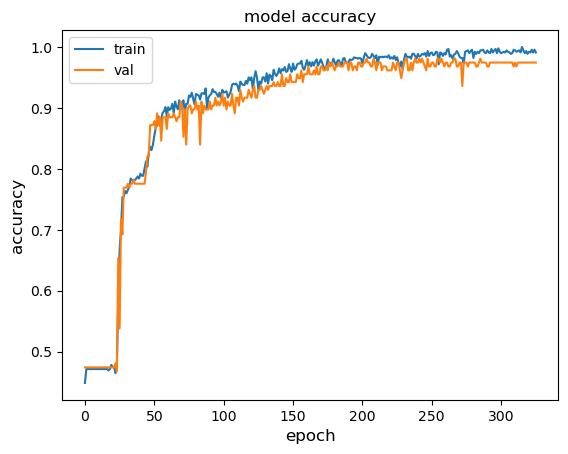

In [27]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")

figname_pdf="MT_{}.pdf".format(model_RNN_name)
figname_png="MT_{}.png".format(model_RNN_name)
plt.savefig(os.path.join(sensor_model_folder,figname_pdf))
plt.savefig(os.path.join(sensor_model_folder,figname_png))

plt.show()
plt.close()


## Evaluation

Load test set (holdout, different from validation set)

In [17]:
#Select sensor csv folder:

# Create and display a FileChooser widget
fc_test = FileChooser('./')
fc_test.show_only_dirs=True
print("------------------------------\nSELECT TEST DATA SENSOR FOLDER\n------------------------------")
display(fc_test)
print("------------------------------\n")

------------------------------
SELECT TEST DATA SENSOR FOLDER
------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

------------------------------



Number of samples: 614
Sample size: 50
Number of features: 3
-----------------------
Plot example for first file:
-----------------------
The class for this file is 2
Shape of the data is: (49, 3)


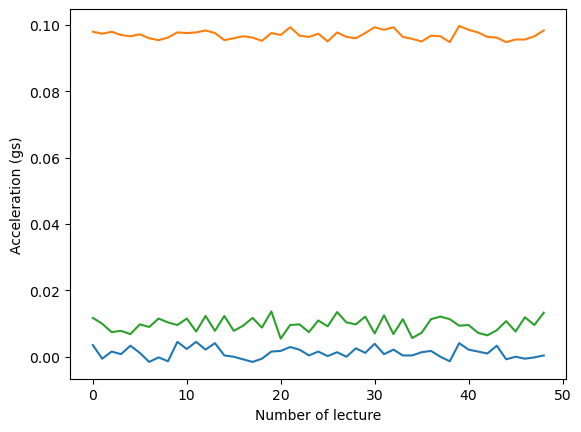

In [18]:
if fc_test.selected_path==None:
    print("No folder specified!! Using validation data as test data...")
    TestDataX=X_test
    TestDataY=y_test
else:
    full_path_test = fc_test.selected_path

    Current_file_path_test = os.path.join(full_path_test,os.listdir(full_path_test)[0])

    Current_file_test = open(Current_file_path_test) # Open first file for counting rows

    num_samples_test= len(os.listdir(full_path_test)) #number of .csv files in total
    tam_samples_test= len(Current_file_test.readlines())#number of lectures in a window sample (rows in each .csv)
    num_features_test = 3 #axis number (3 for accel) TODO: read column number from the file

    print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples_test,tam_samples_test,num_features_test))
    print("-----------------------\nPlot example for first file:\n-----------------------")

    file_class_test=int(Current_file_path_test[-6:-4])-1 # Class is in the filename, at the end, just before file extension
    print("The class for this file is {}".format(file_class_test))

    plot_record(Current_file_path_test, 'Number of lecture', 'Acceleration (gs)')

    Current_file_test.close() # Close file
    
    TestDataX=np.empty([num_samples, tam_samples, num_features]) # Empty numpy array we will fill with data from .csv files
    TestDataY=np.empty([num_samples])

    for i in range (num_samples):
        Current_file_path = os.path.join(full_path,os.listdir(full_path)[i])
        Current_CSV=np.genfromtxt (Current_file_path, delimiter=",")
        TestDataX[i]=Current_CSV

        file_class=int(Current_file_path[-6:-4])
        TestDataY[i]=file_class-1 #first class is class 1, but now we start from 0

    TestDataY = to_categorical(TestDataY)
    
    if np.any(np.isnan(DataX)):
        print("DANGER!! NaN values found in DataX!!")
    
    if np.any(np.isnan(DataY)):
        print("DANGER!! NaN values found in DataY!!")
    

### Predictions made from test (holdout) data

In [19]:
#Select model:

# Create and display a FileChooser widget
fc_model = FileChooser('./')
#fc_test.show_only_dirs=False
print("------------------------------\nSELECT TRAINED MODEL\n------------------------------")
display(fc_model)
print("------------------------------\n")

------------------------------
SELECT TRAINED MODEL
------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

------------------------------



In [20]:
if fc_model.selected_path==None:
    print("No model specified!!")
    #model = tf.keras.models.load_model(os.path.join(sensor_model_folder, best_model_lstm_name))
else:
    model = tf.keras.models.load_model(fc_model.selected)
    pred = model.predict(TestDataX)
    print("--------\nDone!")

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Fill in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /

#### To confusion matrix

In [21]:
y_pred = np.argmax(pred, axis = 1)
#y_pred = to_categorical(y_pred) 
y_pred

array([2, 2, 2, ..., 2, 2, 2], dtype=int64)

In [22]:
p = sklearn.metrics.confusion_matrix(TestDataY.argmax(axis=1), y_pred, labels=[0,1,2])
p

array([[322,   0,   0],
       [  0, 221,   4],
       [  0,   0, 489]], dtype=int64)

In [23]:
p_norm = sklearn.metrics.confusion_matrix(TestDataY.argmax(axis=1), y_pred, labels=[0,1,2], normalize='true')
p_norm

array([[1.   , 0.   , 0.   ],
       [0.   , 0.982, 0.018],
       [0.   , 0.   , 1.   ]])

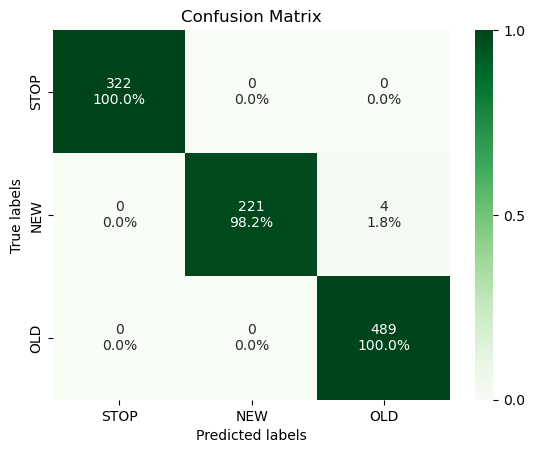

In [26]:
import seaborn as sns

T_lables = ['STOP','NEW','OLD']    

ax= plt.subplot()

# Set values format
values = ["{0:0.0f}".format(x) for x in p.flatten()]

# Find percentages and set format
percentages = ["{0:.1%}".format(x) for x in p_norm.flatten()]

# Combine classes, values and percentages to show 
combined = [f"{i}\n{j}" for i, j in zip(values, percentages)]
combined = np.asarray(combined).reshape(3,3)

sns.heatmap(p_norm, annot=combined, fmt='', ax=ax, cmap="Greens", cbar_kws={"ticks":[0,0.5,1], "format":'%.1f'});  #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(T_lables); ax.yaxis.set_ticklabels(T_lables);

# save the figure
figname_pdf="CM_{}.pdf".format(best_model_RNN_name)
figname_png="CM_{}.png".format(best_model_RNN_name)
plt.savefig(os.path.join(sensor_model_folder,figname_pdf))
plt.savefig(os.path.join(sensor_model_folder,figname_png))

plt.show()
plt.close()

#### More metrics

In [ ]:
report = sklearn.metrics.classification_report(TestDataY.argmax(axis=1),
                                               y_pred,
                                               target_names=['STOP','NEW', 'OLD'],
                                               output_dict=True)
print(report)

---
## Data plot

In [ ]:
# TO DO: METRICS AND PLOT CODE

In [ ]:
# TO DO: METRICS AND PLOT CODE